### **Pandas vs Polars : A walkthrough**
**Came for the speed. Stayed for the syntax.**

In [ ]:
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Pandas
import pandas as pd
df_pd = pd.read_csv("MoviesOnStreamingPlatforms.csv")
print(df_pd.shape)
df_pd.head()

(9515, 11)


,Unnamed: 0,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
0,0,1,The Irishman,2019,18+,98/100,1,0,0,0,0
1,1,2,Dangal,2016,7+,97/100,1,0,0,0,0
2,2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,0
3,3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,0
4,4,5,Roma,2018,18+,94/100,1,0,0,0,0


In [ ]:
# Polars
import polars as pl
df_pl = pl.read_csv("MoviesOnStreamingPlatforms.csv")
print(df_pl.shape)
df_pl.head()

(9515, 11)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type
i64,i64,str,i64,str,str,i64,i64,i64,i64,i64
0,1,"""The Irishman""",2019,"""18+""","""98/100""",1,0,0,0,0
1,2,"""Dangal""",2016,"""7+""","""97/100""",1,0,0,0,0
2,3,"""David Attenborough: A Life on …",2020,"""7+""","""95/100""",1,0,0,0,0
3,4,"""Lagaan: Once Upon a Time in In…",2001,"""7+""","""94/100""",1,0,0,0,0
4,5,"""Roma""",2018,"""18+""","""94/100""",1,0,0,0,0


Notice how the **datatype** of the columns is displayed with the column headers in polars. Also, strings are represented within double quotes.

# **Count of Movies per Streaming Platform**

In [ ]:
# Pandas
platform_cols = ["Netflix","Hulu","Prime Video","Disney+"]
for col in platform_cols:
    print(col, ":", df_pd[col].sum())

Netflix : 3695
Hulu : 1047
Prime Video : 4113
Disney+ : 922


In [ ]:
# Polars
for col in platform_cols:
    print(col, ":", df_pl.select(pl.col(col).sum()).item())

Netflix : 3695
Hulu : 1047
Prime Video : 4113
Disney+ : 922


# **Movies per Release-Year**

In [ ]:
# Pandas
df_pd.groupby("Year").size().sort_values(ascending=False).head()

,0
Year,
2019,1014
2018,945
2020,862
2017,831
2016,644


In [ ]:
# Polars
df_pl.group_by("Year").len().sort("len", descending=True).head()

Year,len
i64,u32
2019,1014
2018,945
2020,862
2017,831
2016,644


# **Unique Counts for Important Columns**

In [ ]:
# Pandas
print('Type value counts:')
print(df_pd['Type'].value_counts(dropna=False))
print('\nAge value counts:')
print(df_pd['Age'].value_counts(dropna=False))
print('\nYear unique count:', df_pd['Year'].nunique())

Type value counts:
Type
0    9515
Name: count, dtype: int64

Age value counts:
Age
NaN    4177
18+    2276
7+     1090
13+     998
all     698
16+     276
Name: count, dtype: int64

Year unique count: 103


In [ ]:
# Polars
print('Type value counts:')
print(df_pl.group_by('Type').len().sort('len', descending=True))
print('\nAge value counts:')
print(df_pl.group_by('Age').len().sort('len', descending=True))
print('\nYear unique count:', df_pl.select(pl.col('Year').n_unique()).item())

Type value counts:
shape: (1, 2)
┌──────┬──────┐
│ Type ┆ len  │
│ ---  ┆ ---  │
│ i64  ┆ u32  │
╞══════╪══════╡
│ 0    ┆ 9515 │
└──────┴──────┘

Age value counts:
shape: (6, 2)
┌──────┬──────┐
│ Age  ┆ len  │
│ ---  ┆ ---  │
│ str  ┆ u32  │
╞══════╪══════╡
│ null ┆ 4177 │
│ 18+  ┆ 2276 │
│ 7+   ┆ 1090 │
│ 13+  ┆ 998  │
│ all  ┆ 698  │
│ 16+  ┆ 276  │
└──────┴──────┘

Year unique count: 103


# **Convert Rotten Tomatoes Column to Percent**

In [ ]:
# Convert "94/100" → 0.94
df_pd['Rotten Tomatoes'] = (
    df_pd['Rotten Tomatoes']
      .astype(str)
      .str.extract(r'(\d+)/(\d+)')
      .astype(float)
      .apply(lambda x: x[0] / x[1], axis=1)
)

df_pd['Rotten Tomatoes'].describe()

,Rotten Tomatoes
count,9508.000000
mean,0.535450
std,0.131977
min,0.100000
25%,0.440000
50%,0.520000
75%,0.620000
max,0.980000


In [ ]:
# Polars
rt_clean = (
df_pl.with_columns(
(pl.col("Rotten Tomatoes").str.split("/").list.get(0).cast(pl.Int64) /
pl.col("Rotten Tomatoes").str.split("/").list.get(1).cast(pl.Int64))
.alias("Rotten Tomatoes")))

df_pl = rt_clean
print(df_pl.select("Rotten Tomatoes"))

shape: (9_515, 1)
┌─────────────────┐
│ Rotten Tomatoes │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.98            │
│ 0.97            │
│ 0.95            │
│ 0.94            │
│ 0.94            │
│ …               │
│ 0.14            │
│ 0.13            │
│ 0.13            │
│ 0.1             │
│ 0.1             │
└─────────────────┘


[.with_columns()](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.with_columns.html#polars.DataFrame.with_columns) is a powerful tool in polars. It can easily perform operations using multiple columns concurrently, without the need of assigning unnecessary extra space in memory.

# **Plotting**

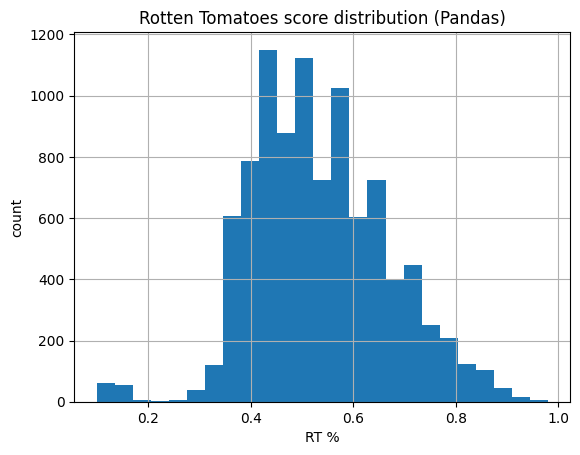

In [ ]:
# Pandas: distribution of Rotten Tomatoes
df_pd['Rotten Tomatoes'].hist(bins=25)
plt.title('Rotten Tomatoes score distribution (Pandas)')
plt.xlabel('RT %')
plt.ylabel('count')
plt.show()

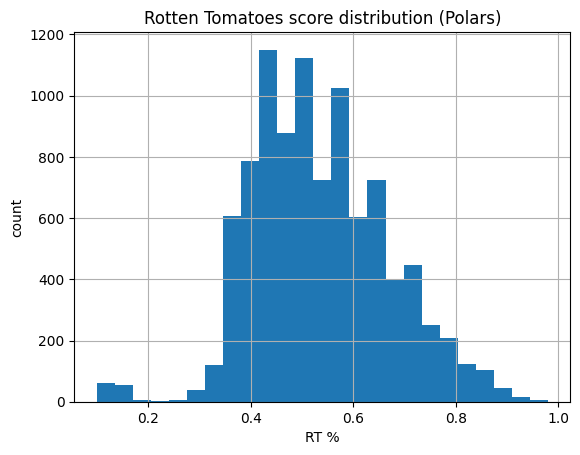

In [ ]:
# Polars: convert to pandas for plotting
df_pl.select('Rotten Tomatoes').to_pandas().hist(bins=25)
plt.title('Rotten Tomatoes score distribution (Polars)')
plt.xlabel('RT %')
plt.ylabel('count')
plt.show()

Another advantage of polars is that pandas functions can directly be used on a daframe. Just convert the polars DF to a pandas DF using [.to_pandas()](https://docs.pola.rs/api/python/stable/reference/dataframe/api/polars.DataFrame.to_pandas.html#polars.DataFrame.to_pandas) and proceed with applying any plotting or other functions from existing libraries. Pretty neat!

*Note : DF should be an eager DF, not a lazy DF. Lazy DF would need a .collect()*

# **Titles per year**

In [ ]:
# Pandas
titles_per_year_pd = df_pd.groupby('Year').size().rename('Number of Movies').reset_index()
print(titles_per_year_pd.sort_values('Number of Movies', ascending=False).head())

     Year  Number of Movies
100  2019              1014
99   2018               945
101  2020               862
98   2017               831
97   2016               644


In [ ]:
# Polars
titles_per_year_pl = df_pl.group_by('Year').len().rename({'len':'Number of Movies'})
print(titles_per_year_pl.sort('Number of Movies', descending=True).head())

shape: (5, 2)
┌──────┬──────────────────┐
│ Year ┆ Number of Movies │
│ ---  ┆ ---              │
│ i64  ┆ u32              │
╞══════╪══════════════════╡
│ 2019 ┆ 1014             │
│ 2018 ┆ 945              │
│ 2020 ┆ 862              │
│ 2017 ┆ 831              │
│ 2016 ┆ 644              │
└──────┴──────────────────┘


# **Top 10 Titles per Platform by Rotten Tomatoes**

In [ ]:
# Pandas
for c in platform_cols:
  temp = df_pd[df_pd[c] == 1].dropna(subset=['Rotten Tomatoes']).sort_values('Rotten Tomatoes', ascending=False).head()
  print(f"Top 10 by Rotten Tomatoes on {c}")
  print(temp[['Title','Year','Rotten Tomatoes']])

Top 10 by Rotten Tomatoes on Netflix
                                      Title  Year  Rotten Tomatoes
0                              The Irishman  2019             0.98
1                                    Dangal  2016             0.97
2  David Attenborough: A Life on Our Planet  2020             0.95
4                                      Roma  2018             0.94
3         Lagaan: Once Upon a Time in India  2001             0.94
Top 10 by Rotten Tomatoes on Hulu
                    Title  Year  Rotten Tomatoes
3695      The Dark Knight  2008             0.94
3696      Minding the Gap  2018             0.90
3698        Batman Begins  2005             0.88
3697             Parasite  2019             0.88
3700  Catch Me If You Can  2002             0.87
Top 10 by Rotten Tomatoes on Prime Video
               Title  Year  Rotten Tomatoes
4703      Fight Club  1999             0.93
4704         Tumbbad  2018             0.93
4705       Gully Boy  2019             0.91
4706  Chak De! I

In [ ]:
# Polars
for c in platform_cols:
  temp = (
  df_pl.filter(pl.col(c) == 1)
  .filter(pl.col('Rotten Tomatoes').is_not_null())
  .sort('Rotten Tomatoes', descending=True)
  .select(['Title','Year','Rotten Tomatoes'])
  .head()
  )
  print(f"Top 10 by Rotten Tomatoes on {c}")
  print(temp)

Top 10 by Rotten Tomatoes on Netflix
shape: (5, 3)
┌─────────────────────────────────┬──────┬─────────────────┐
│ Title                           ┆ Year ┆ Rotten Tomatoes │
│ ---                             ┆ ---  ┆ ---             │
│ str                             ┆ i64  ┆ f64             │
╞═════════════════════════════════╪══════╪═════════════════╡
│ The Irishman                    ┆ 2019 ┆ 0.98            │
│ Dangal                          ┆ 2016 ┆ 0.97            │
│ David Attenborough: A Life on … ┆ 2020 ┆ 0.95            │
│ Lagaan: Once Upon a Time in In… ┆ 2001 ┆ 0.94            │
│ Roma                            ┆ 2018 ┆ 0.94            │
└─────────────────────────────────┴──────┴─────────────────┘
Top 10 by Rotten Tomatoes on Hulu
shape: (5, 3)
┌─────────────────┬──────┬─────────────────┐
│ Title           ┆ Year ┆ Rotten Tomatoes │
│ ---             ┆ ---  ┆ ---             │
│ str             ┆ i64  ┆ f64             │
╞═════════════════╪══════╪═════════════════╡
│ The

# **Platform Counts by Year**

In [ ]:
# Eager version
summary_eager = (
df_pl
.group_by('Year')
.agg([
pl.col('Netflix').sum().alias('Netflix_count'),
pl.col('Hulu').sum().alias('Hulu_count'),
pl.col('Prime Video').sum().alias('Prime_count'),
pl.col('Disney+').sum().alias('Disney_count'),
pl.len().alias('total')
])
.sort('Year', descending=True)
)
print(summary_eager.head())

shape: (5, 6)
┌──────┬───────────────┬────────────┬─────────────┬──────────────┬───────┐
│ Year ┆ Netflix_count ┆ Hulu_count ┆ Prime_count ┆ Disney_count ┆ total │
│ ---  ┆ ---           ┆ ---        ┆ ---         ┆ ---          ┆ ---   │
│ i64  ┆ i64           ┆ i64        ┆ i64         ┆ i64          ┆ u32   │
╞══════╪═══════════════╪════════════╪═════════════╪══════════════╪═══════╡
│ 2021 ┆ 201           ┆ 37         ┆ 63          ┆ 28           ┆ 327   │
│ 2020 ┆ 478           ┆ 116        ┆ 204         ┆ 71           ┆ 862   │
│ 2019 ┆ 573           ┆ 156        ┆ 256         ┆ 50           ┆ 1014  │
│ 2018 ┆ 540           ┆ 108        ┆ 285         ┆ 34           ┆ 945   │
│ 2017 ┆ 449           ┆ 91         ┆ 285         ┆ 28           ┆ 831   │
└──────┴───────────────┴────────────┴─────────────┴──────────────┴───────┘


In [ ]:
# Lazy version (recommended for bigger datasets)
lf = df_pl.lazy()
summary_lazy = (
lf.group_by('Year').agg([
pl.col('Netflix').sum().alias('Netflix_count'),
pl.col('Hulu').sum().alias('Hulu_count'),
pl.col('Prime Video').sum().alias('Prime_count'),
pl.col('Disney+').sum().alias('Disney_count'),
pl.len().alias('total')
])
.sort('Year', descending=True)
)
# nothing executed until collect()
summary_df = summary_lazy.collect()
print(summary_df.head())

shape: (5, 6)
┌──────┬───────────────┬────────────┬─────────────┬──────────────┬───────┐
│ Year ┆ Netflix_count ┆ Hulu_count ┆ Prime_count ┆ Disney_count ┆ total │
│ ---  ┆ ---           ┆ ---        ┆ ---         ┆ ---          ┆ ---   │
│ i64  ┆ i64           ┆ i64        ┆ i64         ┆ i64          ┆ u32   │
╞══════╪═══════════════╪════════════╪═════════════╪══════════════╪═══════╡
│ 2021 ┆ 201           ┆ 37         ┆ 63          ┆ 28           ┆ 327   │
│ 2020 ┆ 478           ┆ 116        ┆ 204         ┆ 71           ┆ 862   │
│ 2019 ┆ 573           ┆ 156        ┆ 256         ┆ 50           ┆ 1014  │
│ 2018 ┆ 540           ┆ 108        ┆ 285         ┆ 34           ┆ 945   │
│ 2017 ┆ 449           ┆ 91         ┆ 285         ┆ 28           ┆ 831   │
└──────┴───────────────┴────────────┴─────────────┴──────────────┴───────┘


# **Polars: Compute Multiple Aggregations in One Pass**

In [ ]:
metrics = (
df_pl.lazy()
.select([
pl.col('Year'),pl.col('Rotten Tomatoes'),pl.col('Netflix'), pl.col('Hulu'),
pl.col('Prime Video'), pl.col('Disney+')
])
.group_by('Year')
.agg([
pl.len().alias('n_titles'),
pl.col('Rotten Tomatoes').mean().alias('mean_rt'),
pl.col('Netflix').sum().alias('netflix'),
pl.col('Hulu').sum().alias('hulu'),
pl.col('Prime Video').sum().alias('prime'),
pl.col('Disney+').sum().alias('disney')
])
.with_columns((pl.col('netflix') / pl.col('n_titles') * 100).alias('pct_netflix'))
.with_columns((pl.col('hulu') / pl.col('n_titles') * 100).alias('pct_hulu'))
.with_columns((pl.col('prime') / pl.col('n_titles') * 100).alias('pct_prime'))
.with_columns((pl.col('disney') / pl.col('n_titles') * 100).alias('pct_disney'))
)
metrics_df = metrics.collect()
print(metrics_df.head())

shape: (5, 11)
┌──────┬──────────┬──────────┬─────────┬───┬─────────────┬──────────┬───────────┬────────────┐
│ Year ┆ n_titles ┆ mean_rt  ┆ netflix ┆ … ┆ pct_netflix ┆ pct_hulu ┆ pct_prime ┆ pct_disney │
│ ---  ┆ ---      ┆ ---      ┆ ---     ┆   ┆ ---         ┆ ---      ┆ ---       ┆ ---        │
│ i64  ┆ u32      ┆ f64      ┆ i64     ┆   ┆ f64         ┆ f64      ┆ f64       ┆ f64        │
╞══════╪══════════╪══════════╪═════════╪═══╪═════════════╪══════════╪═══════════╪════════════╡
│ 1966 ┆ 10       ┆ 0.549    ┆ 1       ┆ … ┆ 10.0        ┆ 10.0     ┆ 70.0      ┆ 10.0       │
│ 2004 ┆ 109      ┆ 0.587615 ┆ 30      ┆ … ┆ 27.522936   ┆ 6.422018 ┆ 53.211009 ┆ 18.348624  │
│ 1990 ┆ 31       ┆ 0.595161 ┆ 10      ┆ … ┆ 32.258065   ┆ 9.677419 ┆ 38.709677 ┆ 19.354839  │
│ 1992 ┆ 52       ┆ 0.589615 ┆ 9       ┆ … ┆ 17.307692   ┆ 9.615385 ┆ 63.461538 ┆ 15.384615  │
│ 2007 ┆ 149      ┆ 0.559195 ┆ 35      ┆ … ┆ 23.489933   ┆ 9.395973 ┆ 60.402685 ┆ 11.409396  │
└──────┴──────────┴──────────┴─────